In [1]:
import sys
sys.path.append("..")

import pandas as pd

from src.data_loader import load_data

In [2]:
df = load_data("../data/processed/dataset_clean.csv") 

In [3]:
df["recommended_movie_genre"].value_counts()

recommended_movie_genre
Action         1015
Thriller       1013
Drama           990
Documentary     632
Comedy          588
Romance         554
Animation       440
Sci-Fi          399
Horror          369
Name: count, dtype: int64

C:\Users\lucas\AppData\Local\Temp\ipykernel_18660\1321154329.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(dados.values()), y=list(dados.keys()), palette="Blues_r")


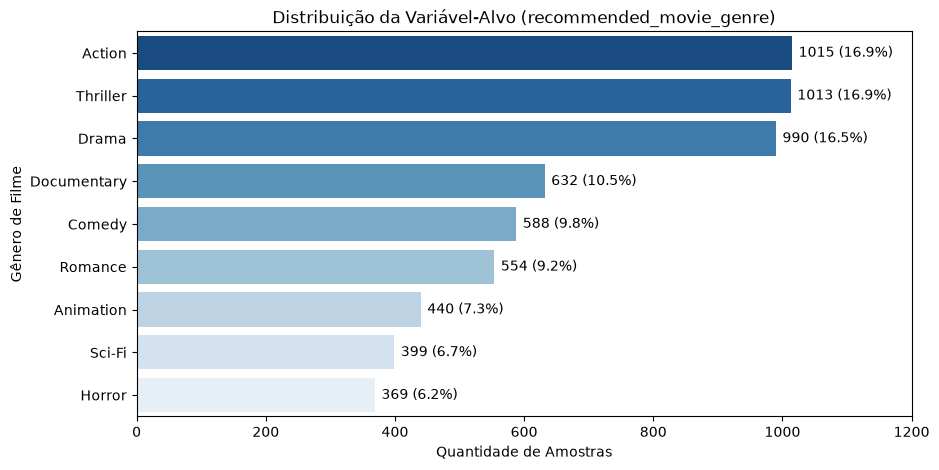

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dados da sua distribuição
dados = {
    'Action': 1015, 'Thriller': 1013, 'Drama': 990,
    'Documentary': 632, 'Comedy': 588, 'Romance': 554,
    'Animation': 440, 'Sci-Fi': 399, 'Horror': 369
}

# Criando o gráfico
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=list(dados.values()), y=list(dados.keys()), palette="Blues_r")

# Adicionando o valor absoluto e a porcentagem em cada barra
total = sum(dados.values())
for p in ax.patches:
    width = p.get_width()
    pct = (width / total) * 100
    ax.annotate(f'{int(width)} ({pct:.1f}%)',
                (width + 10, p.get_y() + p.get_height() / 2.),
                va='center')

plt.title('Distribuição da Variável-Alvo (recommended_movie_genre)')
plt.xlabel('Quantidade de Amostras')
plt.ylabel('Gênero de Filme')
plt.xlim(0, 1200) # Espaço para os rótulos
plt.show()

In [7]:
pd.crosstab(
    df["personality_type"],
    df["recommended_movie_genre"],
    normalize="index"
)

recommended_movie_genre,Action,Animation,Comedy,Documentary,Drama,Horror,Romance,Sci-Fi,Thriller
personality_type,,,,,,,,,
Ambivert,0.140581,0.061468,0.114969,0.100740,0.166192,0.062607,0.108708,0.049516,0.195219
Extrovert,0.233599,0.067376,0.112589,0.079787,0.160461,0.063387,0.073138,0.062057,0.147606
Introvert,0.121288,0.090589,0.066432,0.138400,0.169099,0.058379,0.099648,0.086563,0.169602


In [8]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(
    df["personality_type"],
    df["recommended_movie_genre"]
)

chi2, p, dof, expected = chi2_contingency(tabela)

print("Qui-quadrado:", chi2)
print("p-valor:", p)
print("Graus de liberdade:", dof)

Qui-quadrado: 218.35806429945913
p-valor: 1.503783141192388e-37
Graus de liberdade: 16


In [9]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("V de Cramér:", cramers_v(tabela))

V de Cramér: 0.13489442300661753


### Interpretação: Qui-quadrado e V de Cramér

- **Qui-quadrado:** verifica se existe uma associação estatisticamente significativa entre duas variáveis categóricas.
  - `p < 0,05` → há evidência de associação.
  - `p >= 0,05` → não há evidência suficiente de associação.

- **V de Cramér:** mede a **intensidade** dessa associação, variando de 0 a 1.
  - Próximo de 0 → associação fraca.
  - Próximo de 1 → associação forte.

**Importante:** uma associação pode ser estatisticamente significativa e, mesmo assim, ser fraca. Por isso, devemos analisar o **p-valor e o V de Cramér juntos**.

`personality_type` apresentou `p ≈ 1,50 × 10⁻³⁷` e `V = 0,135`. Portanto, existe uma associação estatisticamente significativa com `recommended_movie_genre`, mas sua intensidade é fraca.


    "relationship_status",
    "favorite_season",
    "sleep_pattern",
    "occupation",
    "preferred_streaming_platform",
    "preferred_watch_time",
    "viewing_companion",
    "snack_preference",
    "preferred_device",
    "favorite_movie_era",
    "pet_ownership",
    "book_reading_frequency"

In [10]:
pd.crosstab(
    df["gender"],
    df["recommended_movie_genre"],
    normalize="index"
)

recommended_movie_genre,Action,Animation,Comedy,Documentary,Drama,Horror,Romance,Sci-Fi,Thriller
gender,,,,,,,,,
Female,0.171947,0.075828,0.099324,0.102172,0.173015,0.058028,0.093984,0.062656,0.163047
Male,0.165196,0.073067,0.095305,0.104130,0.155665,0.066008,0.091776,0.071655,0.177197
Non-binary,0.178771,0.055866,0.108939,0.139665,0.175978,0.053073,0.083799,0.055866,0.148045


In [12]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(
    df["gender"],
    df["recommended_movie_genre"]
)

chi2, p, dof, expected = chi2_contingency(tabela)

print("Qui-quadrado:", chi2)
print("p-valor:", p)
print("Graus de liberdade:", dof)

Qui-quadrado: 17.46565414665575
p-valor: 0.3561006450896204
Graus de liberdade: 16


In [13]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("V de Cramér:", cramers_v(tabela))

V de Cramér: 0.038150637987954795


### Resultado — gender

O teste de qui-quadrado apresentou p-valor de 0,3561, superior ao nível de significância de 5%. Portanto, não foi encontrada evidência estatística suficiente de associação entre `gender` e `recommended_movie_genre`. O V de Cramér foi de 0,0382, indicando uma associação muito fraca entre as variáveis.

In [14]:
pd.crosstab(
    df["favorite_game_genre"],
    df["recommended_movie_genre"],
    normalize="index"
)

recommended_movie_genre,Action,Animation,Comedy,Documentary,Drama,Horror,Romance,Sci-Fi,Thriller
favorite_game_genre,,,,,,,,,
Action,0.384454,0.055672,0.101891,0.077731,0.128151,0.021008,0.073529,0.027311,0.130252
Horror/Survival,0.070000,0.066667,0.068333,0.088333,0.160000,0.325000,0.080000,0.023333,0.118333
Nao_Informado,0.102778,0.094444,0.102778,0.130556,0.219444,0.038889,0.094444,0.052778,0.163889
Puzzle,0.123337,0.076179,0.103990,0.125756,0.199516,0.029021,0.122128,0.051995,0.168077
RPG,0.115124,0.062077,0.102709,0.098194,0.154628,0.032731,0.098194,0.155756,0.180587
Racing,0.375000,0.056818,0.090909,0.104545,0.125000,0.027273,0.097727,0.025000,0.097727
Simulation,0.123100,0.088146,0.104863,0.133739,0.186930,0.044073,0.092705,0.048632,0.177812
Sports,0.107203,0.092127,0.093802,0.125628,0.197655,0.046901,0.097152,0.038526,0.201005
Strategy,0.082353,0.083824,0.104412,0.085294,0.139706,0.026471,0.076471,0.136765,0.264706


In [15]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(
    df["favorite_game_genre"],
    df["recommended_movie_genre"]
)

chi2, p, dof, expected = chi2_contingency(tabela)

print("Qui-quadrado:", chi2)
print("p-valor:", p)
print("Graus de liberdade:", dof)

Qui-quadrado: 1640.9912244066668
p-valor: 1.262788375050004e-300
Graus de liberdade: 64


In [16]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("V de Cramér:", cramers_v(tabela))

V de Cramér: 0.18489812647817416


### Resultado — favorite_game_genre

O teste de qui-quadrado apresentou p-valor inferior a 0,05, indicando uma associação estatisticamente significativa entre `favorite_game_genre` e `recommended_movie_genre`. O V de Cramér foi de 0,1849, indicando uma associação de baixa intensidade. Entre as features categóricas analisadas até o momento, `favorite_game_genre` apresentou a maior intensidade de associação com o target.

In [17]:
pd.crosstab(
    df["favorite_music_genre"],
    df["recommended_movie_genre"],
    normalize="index"
)

recommended_movie_genre,Action,Animation,Comedy,Documentary,Drama,Horror,Romance,Sci-Fi,Thriller
favorite_music_genre,,,,,,,,,
Classical,0.174737,0.071579,0.096842,0.090526,0.168421,0.061053,0.092632,0.052632,0.191579
Country,0.150313,0.079332,0.085595,0.114823,0.173278,0.035491,0.081420,0.075157,0.204593
EDM,0.193760,0.073892,0.118227,0.098522,0.152709,0.049261,0.103448,0.055829,0.154351
Hip-Hop,0.169528,0.066524,0.127682,0.099785,0.150215,0.074034,0.082618,0.060086,0.169528
Indie,0.182566,0.087171,0.077303,0.101974,0.162829,0.072368,0.101974,0.072368,0.141447
Jazz,0.139276,0.075209,0.080780,0.114206,0.197772,0.058496,0.089136,0.089136,0.155989
Nao_Informado,0.165730,0.056180,0.134831,0.103933,0.157303,0.050562,0.092697,0.081461,0.157303
Pop,0.164629,0.076610,0.092095,0.111654,0.161369,0.066015,0.092095,0.063570,0.171964
Rock,0.169634,0.070157,0.076440,0.108901,0.178010,0.062827,0.095288,0.068063,0.170681


In [19]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(
    df["favorite_music_genre"],
    df["recommended_movie_genre"]
)

chi2, p, dof, expected = chi2_contingency(tabela)

print("Qui-quadrado:", chi2)
print("p-valor:", p)
print("Graus de liberdade:", dof)

Qui-quadrado: 75.82406776785875
p-valor: 0.14800791604584335
Graus de liberdade: 64


In [20]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("V de Cramér:", cramers_v(tabela))

V de Cramér: 0.03974503841358135


### Resultado — favorite_music_genre

O teste de qui-quadrado apresentou p-valor de 0,1480, superior ao nível de significância de 5%. Portanto, não foi encontrada evidência estatística suficiente de associação entre `favorite_music_genre` e `recommended_movie_genre`. O V de Cramér foi de 0,0397, indicando uma associação muito fraca entre as variáveis.

In [21]:
pd.crosstab(
    df["preferred_language"],
    df["recommended_movie_genre"],
    normalize="index"
)

recommended_movie_genre,Action,Animation,Comedy,Documentary,Drama,Horror,Romance,Sci-Fi,Thriller
preferred_language,,,,,,,,,
English,0.164562,0.072811,0.099327,0.113636,0.168350,0.053872,0.092172,0.069865,0.165404
French,0.182867,0.064250,0.102142,0.108731,0.154860,0.065898,0.092257,0.060956,0.168040
Hindi,0.171256,0.078313,0.111015,0.090361,0.166954,0.063683,0.091222,0.063683,0.163511
Japanese,0.184100,0.069038,0.077406,0.102510,0.150628,0.060669,0.098326,0.050209,0.207113
Korean,0.169463,0.072148,0.085570,0.098993,0.182886,0.057047,0.095638,0.065436,0.172819
Spanish,0.160051,0.078105,0.093470,0.106274,0.154930,0.081946,0.088348,0.075544,0.161332


In [31]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(
    df["preferred_language"],
    df["recommended_movie_genre"]
)

chi2, p, dof, expected = chi2_contingency(tabela)

print("Qui-quadrado:", chi2)
print("p-valor:", p)
print("Graus de liberdade:", dof)

Qui-quadrado: 32.94115092297377
p-valor: 0.7779554870145644
Graus de liberdade: 40


In [32]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("V de Cramér:", cramers_v(tabela))

V de Cramér: 0.033136661933561226


### Resultado — preferred_language

O teste de qui-quadrado apresentou p-valor de 0,7780, superior ao nível de significância de 5%. Portanto, não foi encontrada evidência estatística suficiente de associação entre `preferred_language` e `recommended_movie_genre`. O V de Cramér foi de 0,0331, indicando uma associação muito fraca entre as variáveis.

In [26]:
pd.crosstab(
    df["relationship_status"],
    df["recommended_movie_genre"],
    normalize="index"
)

recommended_movie_genre,Action,Animation,Comedy,Documentary,Drama,Horror,Romance,Sci-Fi,Thriller
relationship_status,,,,,,,,,
Divorced,0.183442,0.066558,0.094156,0.110390,0.180195,0.058442,0.058442,0.084416,0.163961
In a relationship,0.157736,0.072453,0.091321,0.108679,0.157736,0.059623,0.116981,0.058113,0.177358
Married,0.159117,0.072590,0.102207,0.096400,0.165505,0.057491,0.114983,0.056911,0.174797
Single,0.179290,0.076166,0.099700,0.108686,0.164741,0.066324,0.070603,0.073599,0.160890


In [37]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(
    df["relationship_status"],
    df["recommended_movie_genre"]
)

chi2, p, dof, expected = chi2_contingency(tabela)

print("Qui-quadrado:", chi2)
print("p-valor:", p)
print("Graus de liberdade:", dof)

Qui-quadrado: 58.910749104275496
p-valor: 9.086715726692828e-05
Graus de liberdade: 24


In [34]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("V de Cramér:", cramers_v(tabela))

V de Cramér: 0.057208560501746344


### Resultado — relationship_status

O teste de qui-quadrado apresentou p-valor de 0,00009, inferior ao nível de significância de 5%. Portanto, foi encontrada evidência estatística de associação entre `relationship_status` e `recommended_movie_genre`. Entretanto, o V de Cramér foi de 0,0572, indicando que essa associação é muito fraca.

In [38]:
pd.crosstab(
    df["favorite_season"],
    df["recommended_movie_genre"],
    normalize="index"
)

recommended_movie_genre,Action,Animation,Comedy,Documentary,Drama,Horror,Romance,Sci-Fi,Thriller
favorite_season,,,,,,,,,
Autumn,0.179209,0.079082,0.082270,0.104592,0.171556,0.056122,0.092474,0.063776,0.170918
Spring,0.169108,0.071904,0.096538,0.093209,0.170439,0.059920,0.096538,0.067244,0.175100
Summer,0.163136,0.078390,0.105932,0.117938,0.139124,0.068503,0.092514,0.079096,0.155367
Winter,0.164465,0.064069,0.108322,0.106341,0.177015,0.062087,0.087847,0.056803,0.173052


In [39]:
from scipy.stats import chi2_contingency

tabela = pd.crosstab(
    df["favorite_season"],
    df["recommended_movie_genre"]
)

chi2, p, dof, expected = chi2_contingency(tabela)

print("Qui-quadrado:", chi2)
print("p-valor:", p)
print("Graus de liberdade:", dof)

Qui-quadrado: 33.33201537566098
p-valor: 0.09725955116885686
Graus de liberdade: 24


In [40]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

print("V de Cramér:", cramers_v(tabela))

V de Cramér: 0.043032297544764744


In [8]:
from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd

def analisar_categorica(df, coluna, target):
    tabela = pd.crosstab(df[coluna], df[target])

    chi2, p, dof, expected = chi2_contingency(tabela)

    n = tabela.sum().sum()
    r, k = tabela.shape

    v_cramer = np.sqrt(
        chi2 / (n * (min(r, k) - 1))
    )

    return {
        "feature": coluna,
        "qui_quadrado": chi2,
        "p_valor": p,
        "v_cramer": v_cramer
    }

In [42]:
colunas_categoricas = [
    "gender",
    "personality_type",
    "favorite_game_genre",
    "favorite_music_genre",
    "preferred_language",
    "relationship_status",
    "favorite_season",
    "sleep_pattern",
    "occupation",
    "preferred_streaming_platform",
    "preferred_watch_time",
    "viewing_companion",
    "snack_preference",
    "preferred_device",
    "favorite_movie_era",
    "pet_ownership",
    "book_reading_frequency"
]

In [43]:
resultados = []

for coluna in colunas_categoricas:
    resultado = analisar_categorica(
        df,
        coluna,
        "recommended_movie_genre"
    )
    
    resultados.append(resultado)

resultados_df = pd.DataFrame(resultados)

resultados_df

,feature,qui_quadrado,p_valor,v_cramer
0,gender,17.465654,3.561006e-01,0.038151
1,personality_type,218.358064,1.503783e-37,0.134894
2,favorite_game_genre,1640.991224,1.262788e-300,0.184898
3,favorite_music_genre,75.824068,1.480079e-01,0.039745
4,preferred_language,32.941151,7.779555e-01,0.033137
5,relationship_status,58.910749,9.086716e-05,0.057209
6,favorite_season,33.332015,9.725955e-02,0.043032
7,sleep_pattern,6.633678,9.796927e-01,0.023512
8,occupation,87.000297,2.774547e-01,0.042574
9,preferred_streaming_platform,34.845400,9.221627e-01,0.031112


In [44]:
resultados_df.sort_values(
    by="v_cramer",
    ascending=False
)

,feature,qui_quadrado,p_valor,v_cramer
2,favorite_game_genre,1640.991224,1.262788e-300,0.184898
1,personality_type,218.358064,1.503783e-37,0.134894
5,relationship_status,58.910749,9.086716e-05,0.057209
16,book_reading_frequency,74.174804,3.377023e-05,0.055593
6,favorite_season,33.332015,9.725955e-02,0.043032
8,occupation,87.000297,2.774547e-01,0.042574
3,favorite_music_genre,75.824068,1.480079e-01,0.039745
12,snack_preference,47.345692,1.978489e-01,0.039726
14,favorite_movie_era,35.659478,3.002198e-01,0.038546
0,gender,17.465654,3.561006e-01,0.038151


In [5]:
colunas_categoricas_ordinais = [
    "age_group",
    "education_level",
    "income_bracket",
    "exercise_frequency",
    "travel_frequency",
    "preferred_movie_length",
]

In [9]:
resultados = []

for coluna in colunas_categoricas_ordinais:
    resultado = analisar_categorica(
        df,
        coluna,
        "recommended_movie_genre"
    )
    
    resultados.append(resultado)

resultados_df = pd.DataFrame(resultados)

resultados_df

,feature,qui_quadrado,p_valor,v_cramer
0,age_group,1059.391787,5.156408e-202,0.210098
1,education_level,35.738739,2.970284e-01,0.038589
2,income_bracket,18.537806,9.722549e-01,0.027792
3,exercise_frequency,44.920552,6.440300e-02,0.043263
4,travel_frequency,25.785865,7.730006e-01,0.032778
5,preferred_movie_length,28.314301,2.470066e-01,0.039661
